In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

In [2]:
@dataclass
class Config:
    image_size = (128, 128)
    batch_size = 32
    epochs = 15
    learning_rate = 0.0001
    device = "cuda" if torch.cuda.is_available() else "cpu"
    train_split = 0.8

config = Config()

In [5]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, dropout_rate=0.1):
        super(UNet, self).__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True)
            )

        self.enc1 = conv_block(in_channels, 64)
        self.enc2 = conv_block(64, 128)
        self.bottleneck = conv_block(128, 256)
        self.drop = nn.Dropout2d(dropout_rate)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(128, 64)

        self.final = nn.Conv2d(64, out_channels, kernel_size=1)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))

        b = self.bottleneck(self.pool(e2))
        b = self.drop(b)

        d2 = self.up2(b)
        d2 = self.dec2(torch.cat((e2, d2), dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat((e1, d1), dim=1))

        return self.final(d1)

In [6]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [7]:
class Trainer:
    def __init__(self, config):
        self.config = config
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

        self.model = UNet(dropout_rate=0.1).to(config.device)
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")

        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()
        print(f"Test Loss: {test_loss:.4f}, Test IoU: {test_iou:.4f}, Test F1-score: {test_f1:.4f}")

    def train(self):
        self.model.train()
        epoch_loss = 0
        for images, masks in tqdm(self.train_dataloader, desc="Training"):
            images, masks = images.to(self.config.device), masks.to(self.config.device)
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, masks)
            loss.backward()
            self.optimizer.step()
            epoch_loss += loss.item()
        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []
        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader, desc="Validating"):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                val_loss += loss.item()
                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)
                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []
        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader, desc="Testing"):
                images, masks = images.to(self.config.device), masks.to(self.config.device)
                outputs = self.model(images)
                loss = self.criterion(outputs, masks)
                test_loss += loss.item()
                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks_np = masks.squeeze(1).cpu().numpy().astype(np.uint8)
                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks_np[i].flatten(), pred_masks[i].flatten(), average='binary'))
        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()
        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))
            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)
                output = torch.sigmoid(self.model(img_tensor)).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')
                axes[i, 0].imshow(img.permute(1, 2, 0).cpu()); axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray"); axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray"); axes[i, 2].set_title("Predicted Mask")
            plt.show()


Запуск эксперимента: LR_0.001


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
100%|██████████| 792M/792M [00:35<00:00, 22.2MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.1MB/s]
Validating: 100%|██████████| 23/23 [00:11<00:00,  1.98it/s]


Epoch 1 / 5, Train Loss: 0.5046, Val Loss: 0.4398, Val IoU: 0.7471, Val F1-score: 0.8467


Validating: 100%|██████████| 23/23 [00:11<00:00,  2.04it/s]


Epoch 2 / 5, Train Loss: 0.4047, Val Loss: 0.3961, Val IoU: 0.7490, Val F1-score: 0.8485


...

Epoch 4 / 5, Train Loss: 0.3480, Val Loss: 0.3495, Val IoU: 0.7977, Val F1-score: 0.8814


Validating: 100%|██████████| 23/23 [00:11<00:00,  2.05it/s]


Epoch 5 / 5, Train Loss: 0.3269, Val Loss: 0.3097, Val IoU: 0.8243, Val F1-score: 0.8986
Testing...


Testing: 100%|██████████| 115/115 [00:56<00:00,  2.02it/s]

Test Loss: 0.3084, Test IoU: 0.8222, Test F1-score: 0.8965


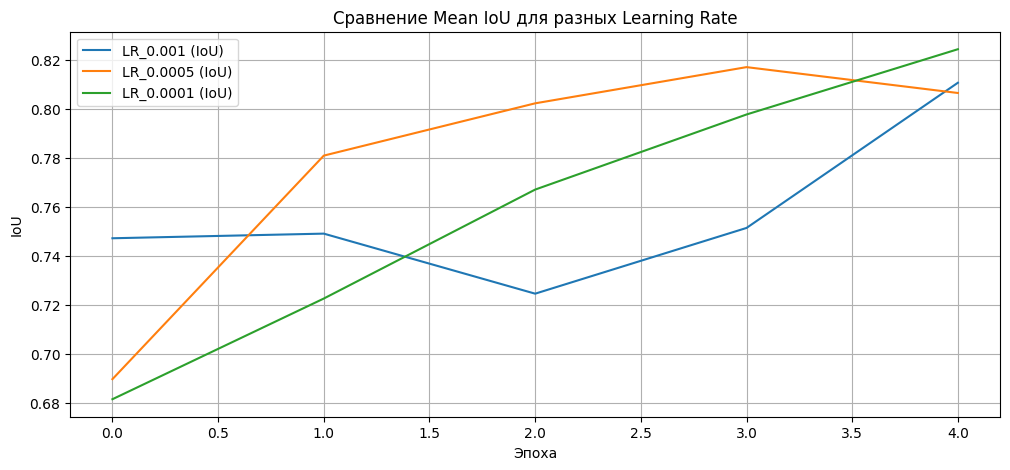

In [8]:
import copy

#эксперимент с разными Learning Rate
experiment_results = {}
lrs = [1e-3, 5e-4, 1e-4]

for lr in lrs:
    exp_name = f"LR_{lr}"
    print(f"\nЗапуск эксперимента: {exp_name}")
    config.learning_rate = lr
    config.epochs = 5 #

    trainer_exp = Trainer(config)
    trainer_exp.run()
    experiment_results[exp_name] = copy.deepcopy(trainer_exp.history)

plt.figure(figsize=(12, 5))
for name, hist in experiment_results.items():
    plt.plot(hist['val_iou'], label=f"{name} (IoU)")
plt.title("Сравнение Mean IoU для разных Learning Rate")
plt.xlabel("Эпоха"); plt.ylabel("IoU"); plt.legend(); plt.grid(True); plt.show()

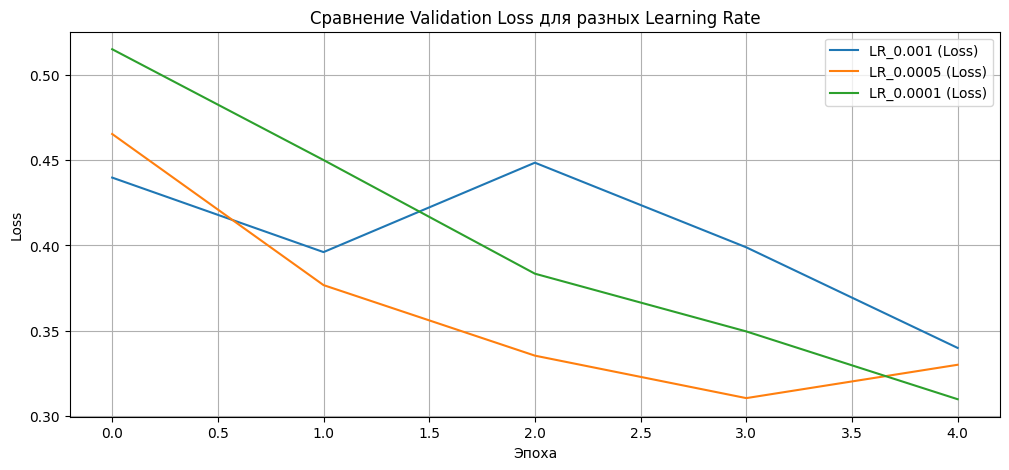

Итоговые результаты экспериментов
Эксперимент LR_0.001: Лучший IoU = 0.8106
Эксперимент LR_0.0005: Лучший IoU = 0.8170
Эксперимент LR_0.0001: Лучший IoU = 0.8243


In [9]:
#график сравнения Loss
plt.figure(figsize=(12, 5))
for name, hist in experiment_results.items():
    plt.plot(hist['val_loss'], label=f"{name} (Loss)")
plt.title("Сравнение Validation Loss для разных Learning Rate")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print("Итоговые результаты экспериментов")
for name, hist in experiment_results.items():
    best_iou = max(hist['val_iou'])
    print(f"Эксперимент {name}: Лучший IoU = {best_iou:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(



Запуск финальной модели (LR=0.0005, Epochs=15)...


Validating: 100%|██████████| 46/46 [00:12<00:00,  3.61it/s]


Epoch 1 / 15, Train Loss: 0.4790, Val Loss: 0.3753, Val IoU: 0.7769, Val F1-score: 0.8672


Validating: 100%|██████████| 46/46 [00:12<00:00,  3.75it/s]


...

Epoch 14 / 15, Train Loss: 0.2119, Val Loss: 0.2235, Val IoU: 0.8645, Val F1-score: 0.9237


Validating: 100%|██████████| 46/46 [00:14<00:00,  3.19it/s]


Epoch 15 / 15, Train Loss: 0.2095, Val Loss: 0.2102, Val IoU: 0.8726, Val F1-score: 0.9284
Testing...


Testing: 100%|██████████| 230/230 [01:01<00:00,  3.77it/s]


Test Loss: 0.2103, Test IoU: 0.8726, Test F1-score: 0.9277


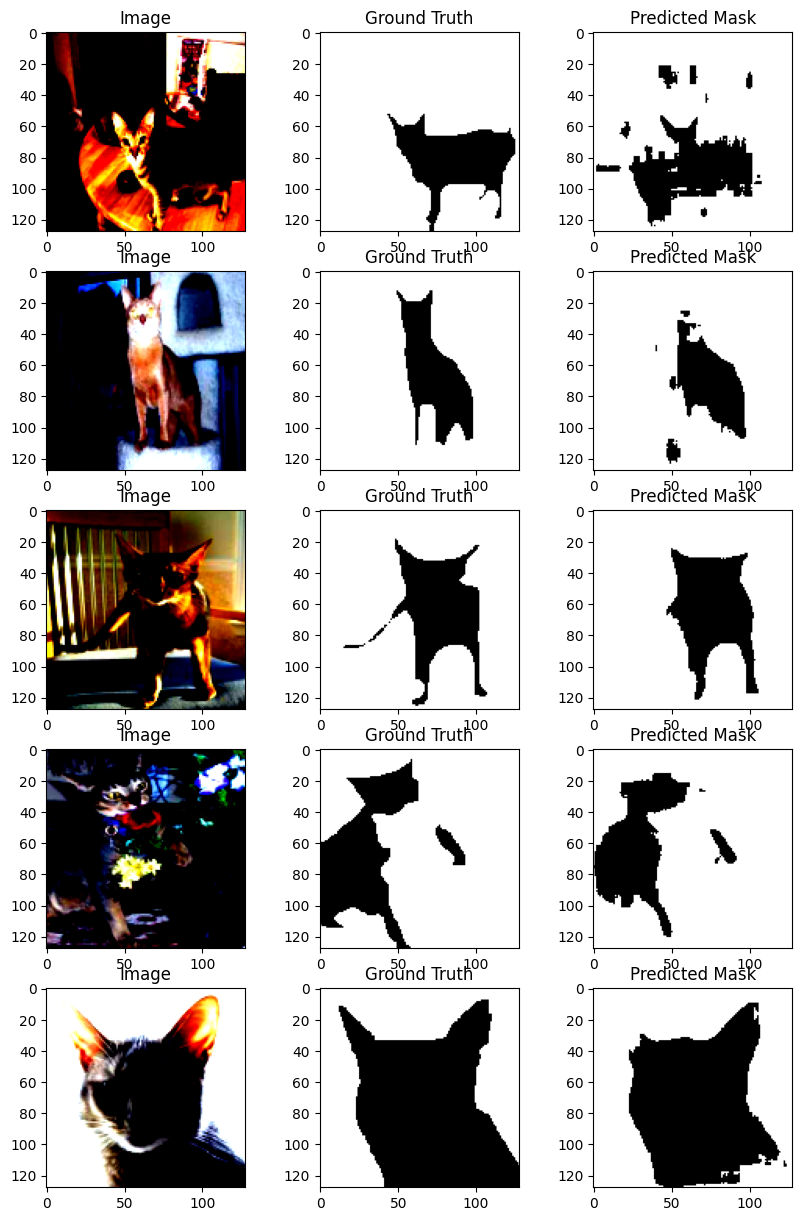

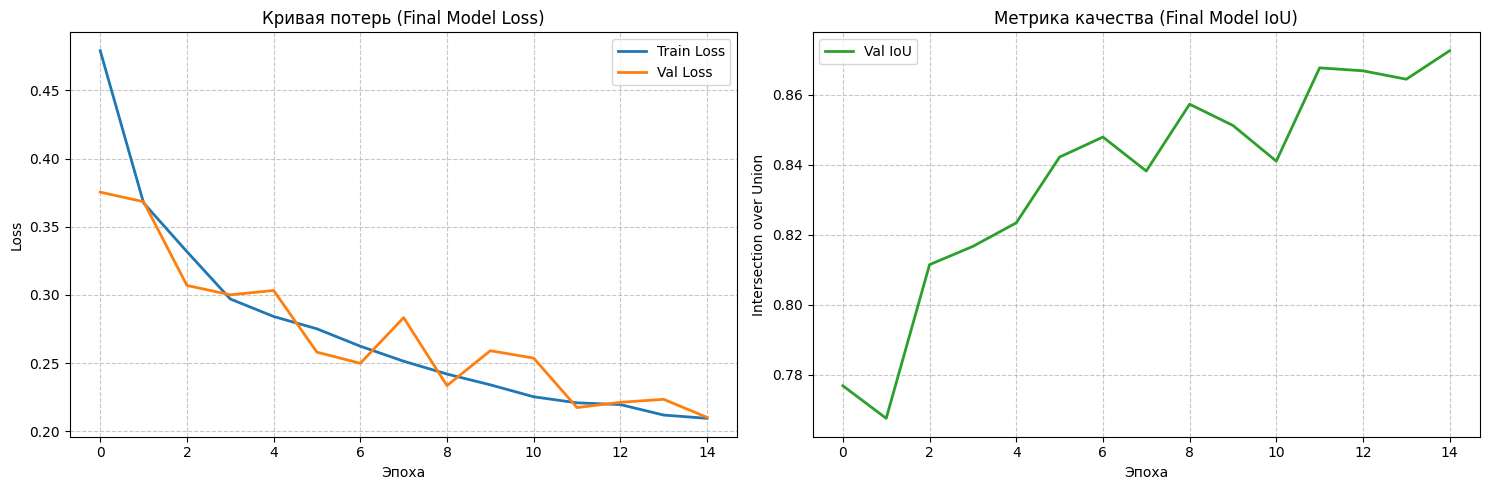

In [13]:
#финальный запуск с лучшими параметрами
config.learning_rate = 5e-4
config.batch_size = 16
config.epochs = 15

print(f"\nЗапуск финальной модели (LR={config.learning_rate}, Epochs={config.epochs})...")
final_trainer = Trainer(config)
final_trainer.run()

final_trainer.inference_and_plot_samples(n_samples=5)

plt.figure(figsize=(15, 5))

#Loss(Обучение и Валидация)
plt.subplot(1, 2, 1)
plt.plot(final_trainer.history['train_loss'], label='Train Loss', color='#1f77b4', lw=2)
plt.plot(final_trainer.history['val_loss'], label='Val Loss', color='#ff7f0e', lw=2)
plt.title('Кривая потерь (Final Model Loss)')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

#IoU
plt.subplot(1, 2, 2)
plt.plot(final_trainer.history['val_iou'], label='Val IoU', color='#2ca02c', lw=2)
plt.title('Метрика качества (Final Model IoU)')
plt.xlabel('Эпоха')
plt.ylabel('Intersection over Union')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


В  U-Net были добавлены BatchNorm2d для ускорения обучения и более высокого Learning rate.Ещё добавлен Dropout(0.1), чтобы не было резкого переобучения.

Было проведено 3 эксперимента с разными скоростями обучения 10^−3, 5*10^−4, 10^−4, самый плавный и стабильный график и IoU, и Loss у 10^−4, лучшие значения тоже у 10^−4.

Кривая Val Loss местами идет близко к Train Loss и не начинает резко расти вверх к последней эпохе, значит Dropout(0.1) хорошо сработал.

Модель неплохая, на тестовых изображениях точно повторяет контуры животных, что подтверждается ростом Mean IoU и F1-score на валидации.